# Toxic Comments Classification - BiLSTM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JigsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: BiLSTM

Preprocessing techniques used:
* Lowercase
* Remove frequent words
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle, time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, recall_score, f1_score, precision_score
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.preprocessing import StandardScaler
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dense, Input, Dropout
from keras import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import text
import re
from nltk.corpus import stopwords
from datetime_extractor import DateTimeExtractor

from tensorflow.keras.layers import Dense, Embedding,GlobalMaxPooling1D, GlobalMaxPool1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical

import seaborn as sns
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set1.csv')
df.head()

,id,comment_text,tox
0,20ca7bad20d4c3d1,"You're an asshole, useless piece of shit. Get ...",1
1,72428510d4205ccf,Nonito Donaire \n\nIt is clearly stated in the...,0
2,f3890d4a31f0d45a,"Okay, in the future I shall no longer use the ...",0
3,29ac5b2897f7ef59,fuck off \n\ndon't fuck with me . fuck off,1
4,6f2278059a63256a,"""*E-dog, on another page, you wrote: \n\nThank...",1


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set1.csv')
test.head()

,id,comment_text,tox
0,b28eeb594e5ac00f,"AAAAWWWW, widdle wikinazis banned me.\n\nMaybe...",1
1,2f3c460abcd5479f,very crocker sucks n e g r o c o c k s i n h e...,1
2,dc3ae57fa0c30d8d,He lied on my RFC too. He's a liar.,1
3,5eb7bb36f870d2b9,"""I've removed the following:\n""""Morro Bay is a...",0
4,e9c9d9abd37bca1d,Briefcase\n\nToo much importance is given to t...,0


# 3. Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))

In [5]:
print(stop_words)

{'what', 'through', 'no', "didn't", "needn't", 'doing', 'myself', 'whom', 'of', 'have', 'above', 'before', 'your', 'her', "it's", 'after', "aren't", 'there', 'how', 'not', 'hadn', 'being', 'if', 'yourselves', 'which', 'both', "she's", 'will', 'hasn', 'for', 'o', 'and', 'off', 'aren', 'couldn', 'having', 'y', "mightn't", 'any', 'same', "mustn't", 'had', 'we', 'just', 've', 'below', 'll', 'from', 'while', 'such', 'don', 'at', 'over', 'once', 'ain', 'a', 'shan', 'theirs', 'with', 'other', 'been', 'has', 'or', 'nor', 'is', 'i', 'my', 'you', 'down', 'ours', "you'd", 'into', 'during', 'as', 'should', 'itself', 'herself', 'isn', 'shouldn', 'yours', "shan't", 'their', 'our', 'only', "wasn't", 'own', 'now', 'but', 'them', 'by', 'doesn', 'some', "shouldn't", 'are', 'than', 'm', "couldn't", 'didn', "you're", 'here', 'was', 'again', 'so', 'in', 'further', 'mightn', 'weren', 'when', 'him', 'who', "weren't", "you'll", 'that', 'up', 'do', 'did', "isn't", 's', 'me', 'themselves', 'between', 'd', 'she'

In [6]:
def convert_lowercase(comment): 

    comment = comment.lower() # Normalize to lowercase 
    
    return comment

In [7]:
# clean and normalize comments
df['comment_text'] = df['comment_text'].map(lambda word:convert_lowercase(word))
test['comment_text'] = test['comment_text'].map(lambda word:convert_lowercase(word))

In [8]:
# find the 10 most frequent words in the train data
dellist1 = pd.Series(' '.join(df['comment_text']).split()).value_counts()[1:10]
print(dellist1)

to      39814
you     39671
a       34334
and     32454
i       32358
of      29764
is      25275
that    19358
in      18422
dtype: int64


In [9]:
# remove the most frequent words from the train data
dellist1 = list(dellist1.index)
df['comment_text'] = df['comment_text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,id,comment_text,tox
0,20ca7bad20d4c3d1,"you're an asshole, useless piece shit. get lif...",1
1,72428510d4205ccf,nonito donaire it clearly stated the given ref...,0
2,f3890d4a31f0d45a,"okay, the future shall no longer use the minor...",0
3,29ac5b2897f7ef59,fuck off don't fuck with me . fuck off,1
4,6f2278059a63256a,"""*e-dog, on another page, wrote: thanks for yo...",1


In [10]:
# find the 10 most frequent words in the test data
dellist2 = pd.Series(' '.join(test['comment_text']).split()).value_counts()[1:10]
print(dellist2)

you     10848
to       9700
a        9032
i        8854
and      8156
of       7228
is       6202
that     4694
in       4408
dtype: int64


In [11]:
# remove the most frequent words from the test data
dellist2 = list(dellist2.index)
test['comment_text'] = test['comment_text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,id,comment_text,tox
0,b28eeb594e5ac00f,"aaaawwww, widdle wikinazis banned me. maybe sh...",1
1,2f3c460abcd5479f,very crocker sucks n e g r o c o c k s n h e l l,1
2,dc3ae57fa0c30d8d,he lied on my rfc too. he's liar.,1
3,5eb7bb36f870d2b9,"""i've removed the following: """"morro bay also ...",0
4,e9c9d9abd37bca1d,briefcase too much importance given the briefc...,0


In [12]:
def clean_text(comment): 

    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [13]:
# clean and normalize comments
df['comment_text'] = df['comment_text'].map(lambda word:clean_text(word))
test['comment_text'] = test['comment_text'].map(lambda word:clean_text(word))

In [14]:
x_train, x_val, y_train, y_val = train_test_split(df['comment_text'], df['tox'], test_size=0.15, random_state=42)

In [15]:
#Check shape of train data
print(x_train.shape)
print(y_train.shape)

(22066,)
(22066,)


In [16]:
#Check shape of validation data
print(x_val.shape)
print(y_val.shape)

(3894,)
(3894,)


In [17]:
x_test = test['comment_text']
y_test = test['tox']

#Check shape of data
print(x_test.shape)
print(y_test.shape)

(6490,)
(6490,)


### Vectorize texts

In [18]:
# Create vocabulary with training texts.
tokenizer = text.Tokenizer(num_words=20000, filters='\r\t\n', lower=False)  # Limit on the number of features. We use the top 20K features.
tokenizer.fit_on_texts(list(x_train)+ list(x_val) + list(x_test))

# Vectorize training texts.
tokenized_train = tokenizer.texts_to_sequences(x_train)
tokenized_val = tokenizer.texts_to_sequences(x_val)
tokenized_test = tokenizer.texts_to_sequences(x_test)

In [19]:
# Limit on the length of text sequences. Sequences longer than this
# will be truncated.
MAX_SEQUENCE_LENGTH = 100


# Get max sequence length.
max_length = len(max(x_train, key=len))
if max_length > MAX_SEQUENCE_LENGTH:
       max_length = MAX_SEQUENCE_LENGTH

In [20]:
# Fix sequence length to max value. Sequences shorter than the length are
# padded in the end and sequences longer are truncated
# at the end.
X_train = pad_sequences(tokenized_train, maxlen=max_length, padding= 'post')
X_val = pad_sequences(tokenized_val, maxlen=max_length, padding= 'post')
X_test = pad_sequences(tokenized_test, maxlen=max_length, padding= 'post')

In [21]:
# Get length of corpus's word index
vocab_size=(len(tokenizer.word_index)+1)
print(vocab_size)

138861


###  converts a class vector (integers) to binary class matrix.

In [22]:
# converts a class vector (integers) to binary class matrix.
Y_train=to_categorical(y_train)
#Check shape of data
Y_train.shape

(22066, 2)

In [23]:
# converts a class vector (integers) to binary class matrix.
Y_val=to_categorical(y_val)
#Check shape of data
Y_val.shape

(3894, 2)

In [24]:
# converts a class vector (integers) to binary class matrix.
Y_test=to_categorical(y_test)
#Check shape of data
Y_test.shape

(6490, 2)

In [25]:
Y_val[:2]

array([[1., 0.],
       [1., 0.]], dtype=float32)

In [26]:
Y_test[:2]

array([[0., 1.],
       [0., 1.]], dtype=float32)

In [27]:
Y_train[:2]

array([[1., 0.],
       [1., 0.]], dtype=float32)

# 3. Create model

In [28]:
EMBEDDING_DIM=400

def model_to_optimize(optimizer='RMSprop'): #learning_rate = 0.001 default value
         
    model = Sequential()
    
    seq = Input(shape=(max_length,))
    input_seq = Embedding(
        input_dim = vocab_size, input_length = max_length,output_dim = EMBEDDING_DIM)(seq)
    
    layer = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(input_seq)
    layer = GlobalMaxPool1D()(layer)
    output = Dense(2, activation='softmax')(layer) 
        
    model = Model(inputs=seq, outputs=output)
        
    model.compile(loss='binary_crossentropy',optimizer=optimizer, metrics=['accuracy'])
    return model

In [29]:
from keras import backend, Model

model_used = model_to_optimize()
# summarize model
model_used.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 100, 400)          55544400  
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 128)          238080    
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 2)                 258       
Total params: 55,782,738
Trainable params: 55,782,738
Non-trainable params: 0
_________________________________________________________________


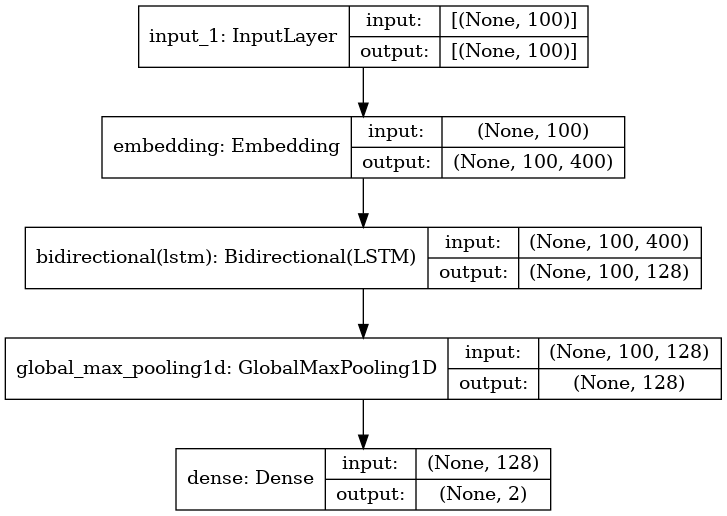

In [30]:
# plot model
plot_model(model_used, show_shapes=True)

In [31]:
## Define your callbacks
Modle_Checkpoint = ModelCheckpoint(
    'models/bilstm_approach#10.h5',
    monitor='val_loss',
    save_best_only='True',
    mode='min',
    verbose=1
)

Early_Stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=1,
    restore_best_weights='True',
    min_delta=0
)

In [32]:
callbacks = [Early_Stopping, Modle_Checkpoint, ]

### Train classifier

In [33]:
history = model_used.fit(X_train,Y_train, epochs=100,
                            callbacks=callbacks,
                            batch_size=128, #litterature review
                            validation_data=(X_val, Y_val),
                            verbose=True)

Epoch 1/100
173/173 [==============================] - 189s 1s/step - loss: 0.4104 - accuracy: 0.8073 - val_loss: 0.2759 - val_accuracy: 0.8796

Epoch 00001: val_loss improved from inf to 0.27589, saving model to models/bilstm_approach#10.h5
Epoch 2/100
173/173 [==============================] - 186s 1s/step - loss: 0.2083 - accuracy: 0.9150 - val_loss: 0.2645 - val_accuracy: 0.8839

Epoch 00002: val_loss improved from 0.27589 to 0.26449, saving model to models/bilstm_approach#10.h5
Epoch 3/100
173/173 [==============================] - 185s 1s/step - loss: 0.1606 - accuracy: 0.9359 - val_loss: 0.2996 - val_accuracy: 0.8834

Epoch 00003: val_loss did not improve from 0.26449
Epoch 4/100
173/173 [==============================] - 187s 1s/step - loss: 0.1272 - accuracy: 0.9508 - val_loss: 0.2897 - val_accuracy: 0.8878

Epoch 00004: val_loss did not improve from 0.26449
Epoch 5/100
173/173 [==============================] - 187s 1s/step - loss: 0.1012 - accuracy: 0.9629 - val_loss: 0.3153

### Evaluate metrics

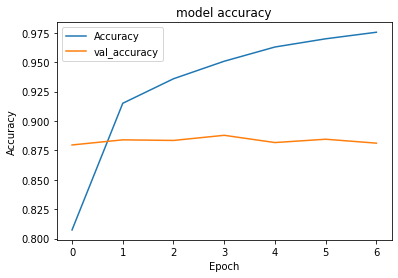

In [34]:
import matplotlib.pyplot as plt
hist = history.history
plt.plot(hist["accuracy"])
plt.plot(hist['val_accuracy'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","val_accuracy"])
plt.show()

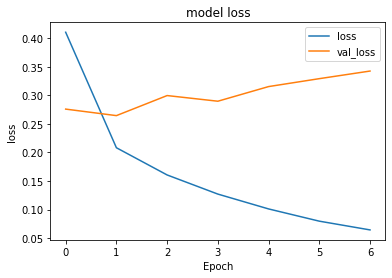

In [35]:
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("Epoch")
plt.legend(["loss","val_loss"])
plt.show()

In [36]:
from keras.models import load_model
saved_model = load_model("models/bilstm_approach#10.h5")

result = saved_model.evaluate(X_train,Y_train,
                               batch_size=128, #litterature review
                            verbose=True)


173/173 [==============================] - 24s 137ms/step - loss: 0.1481 - accuracy: 0.9448


In [37]:
print("train loss: %0.3f" % result[0])
print("train acc: %0.3f" % result[1])

train loss: 0.148
train acc: 0.945


In [38]:
result_val = saved_model.evaluate(X_val,Y_val,
                               batch_size=128, #litterature review
                            verbose=True)

31/31 [==============================] - 4s 139ms/step - loss: 0.2645 - accuracy: 0.8839


In [39]:
print("validation loss: %0.3f" % result_val[0])
print("validation acc: %0.3f" % result_val[1])

validation loss: 0.264
validation acc: 0.884


In [40]:
train_accuracy = "%.4f" % (result[1])
train_Loss = r"%.4f" % (result[0])
val_accuracy = "%.4f" % (result_val[1])
val_loss = "%.4f" % (result_val[0])

# 4. Predictions

### Test set

In [41]:
y_pred=saved_model.predict(X_test, batch_size=128, verbose=True)

51/51 [==============================] - 7s 141ms/step


In [42]:
print(y_pred)

[[1.1847783e-05 9.9998820e-01]
 [1.7824321e-05 9.9998212e-01]
 [2.1467183e-03 9.9785322e-01]
 ...
 [9.9988735e-01 1.1268644e-04]
 [9.9929702e-01 7.0299197e-04]
 [9.9620003e-01 3.7999172e-03]]


In [43]:
print(Y_train)

[[1. 0.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [0. 1.]
 [1. 0.]]


In [44]:
print(Y_test)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [45]:
print("\n Accuracy: %0.2f" % accuracy_score(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))
print("\n Confusion matrix\n")
print(classification_report(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))


 Accuracy: 0.88

 Confusion matrix

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      3221
           1       0.88      0.89      0.89      3269

    accuracy                           0.88      6490
   macro avg       0.88      0.88      0.88      6490
weighted avg       0.88      0.88      0.88      6490



In [46]:
y_pred=np.argmax(y_pred, axis=1)
Y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[2825  396]
 [ 352 2917]]


In [47]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, y_pred))
test_recall  = "%.4f" % (recall_score(Y_test, y_pred))
test_F1_score  = "%.4f" % (f1_score(Y_test, y_pred))
test_precision  = "%.4f" % (precision_score(Y_test, y_pred))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.8847
recall :  0.8923
F1_score :  0.8864
precision :  0.8805


# 5. Save results to Excel file

In [48]:
# define tarjet
newFile = "../results_BiLSTM_set1.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #10', 2:train_accuracy, 3:train_Loss, 4:val_accuracy, 5:val_loss, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach#1
index = 12

# delete row of approach#1
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)